# A decentralized Agentic architecture for real-time compliance and fraud detection in cross-border payment systems

## Load & Merge Multi Source Data

In [1]:
import pandas as pd

transactions = pd.read_csv("transactions_raw.csv")
users = pd.read_csv("users.csv")
devices = pd.read_csv("devices.csv")
ips = pd.read_csv("ips.csv")
merchants = pd.read_csv("merchants.csv")
chargebacks = pd.read_csv("chargebacks.csv")

df = transactions.merge(users, on="user_id", how="left") \
                 .merge(devices, on="device_id", how="left") \
                 .merge(ips, on="ip_id", how="left") \
                 .merge(merchants, on="merchant_id", how="left") \
                 .merge(chargebacks, on="transaction_id", how="left")

print("Chargebacks columns:", chargebacks.columns)
print("Transactions columns:", transactions.columns)

df["is_fraud"] = df["fraud_label"].astype(int)
print(df.shape)

Chargebacks columns: Index(['transaction_id', 'created_at', 'chargeback_at', 'chargeback_reason'], dtype='str')
Transactions columns: Index(['transaction_id', 'created_at', 'user_id', 'device_id', 'ip_id',
       'merchant_id', 'country', 'card_country', 'channel', 'psp_name',
       'payment_method', 'amount', 'bin_risk', 'ip_risk_level',
       'user_age_days', 'email_risk', 'is_3ds', 'retry_count', 'auth_status',
       'decline_code', 'is_psp_outage_window', 'fraud_label'],
      dtype='str')
(120000, 31)


## ACS Feature Engineering

In [2]:
import numpy as np
df["sender_country"] = df["card_country"]
df["receiver_country"] = df["country"]
# Cross-border
df["is_cross_border"] = (df["sender_country"] != df["receiver_country"]).astype(int)

# ISO 20022 simulation
df["message_type"] = np.random.choice(["pacs.008","pacs.009","camt.056"], len(df))
df["purpose_code"] = np.random.choice(["SALA","SUPP","CASH","GDSV"], len(df))

# Jurisdiction rules
THRESHOLDS = {"IN":10000,"US":20000,"UK":15000,"SG":25000,"AE":30000}
df["sender_threshold"] = df["sender_country"].map(THRESHOLDS)
df["receiver_threshold"] = df["receiver_country"].map(THRESHOLDS)

df["compliance_violation"] = (
    (df["amount"] > df["sender_threshold"]) |
    (df["amount"] > df["receiver_threshold"])
).astype(int)

df["created_at_x"] = pd.to_datetime(df["created_at_x"])
df = df.sort_values("created_at_x")

# Ensure time column
time_col = None

if "timestamp" in df.columns:
    time_col = "timestamp"
elif "created_at_x" in df.columns:
    time_col = "created_at_x"
else:
    raise ValueError("No time column found!")

# Convert to datetime
df[time_col] = pd.to_datetime(df[time_col])

# Sort and compute streaming feature
df = df.sort_values(time_col)
df["time_diff"] = df[time_col].diff().dt.total_seconds().fillna(0)

# Behavioral features
df["tx_count_user"] = df.groupby("user_id")["transaction_id"].transform("count")
df["avg_amount_user"] = df.groupby("user_id")["amount"].transform("mean")

# Risk scores
df["velocity_score"] = np.random.rand(len(df))
df["device_risk_score"] = np.random.rand(len(df))

### EDA

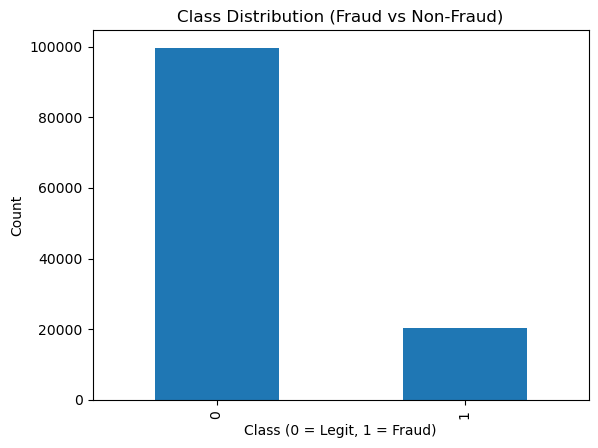

In [3]:
import matplotlib.pyplot as plt

df["is_fraud"].value_counts().plot(kind="bar")
plt.title("Class Distribution (Fraud vs Non-Fraud)")
plt.xlabel("Class (0 = Legit, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

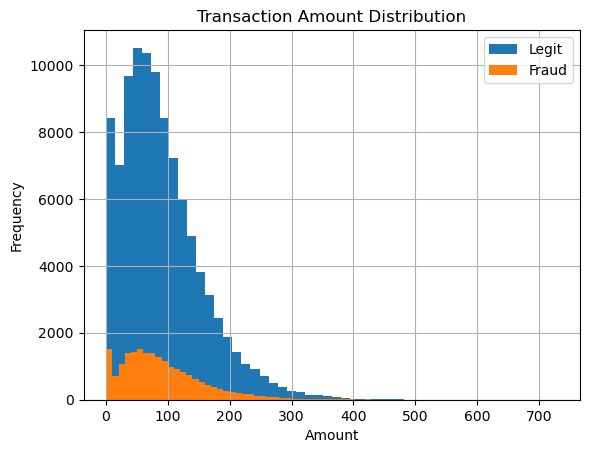

In [4]:
plt.figure()
df[df["is_fraud"]==0]["amount"].hist(bins=50)
df[df["is_fraud"]==1]["amount"].hist(bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.legend(["Legit", "Fraud"])
plt.show()

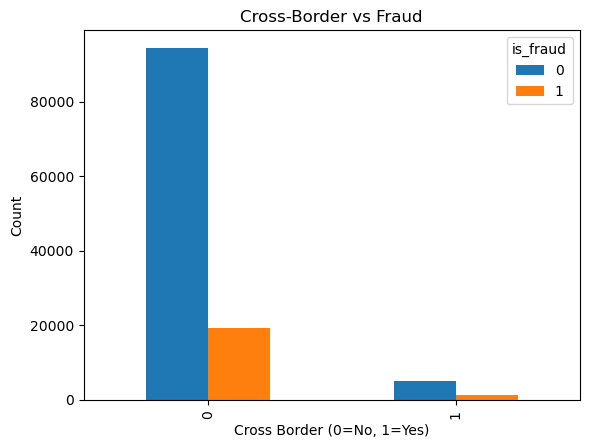

In [5]:
import pandas as pd

cross_tab = pd.crosstab(df["is_cross_border"], df["is_fraud"])

cross_tab.plot(kind="bar")
plt.title("Cross-Border vs Fraud")
plt.xlabel("Cross Border (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

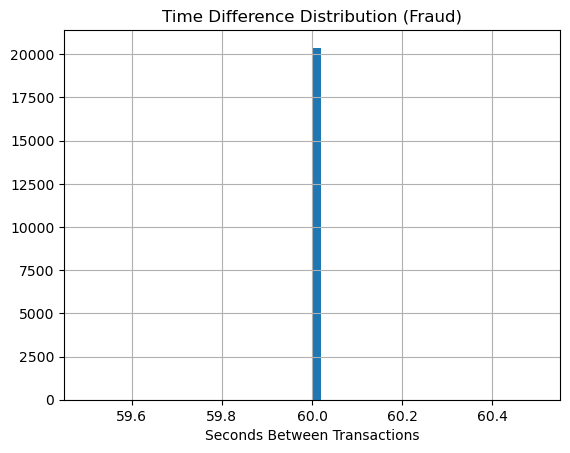

In [6]:
plt.figure()
df[df["is_fraud"]==1]["time_diff"].hist(bins=50)
plt.title("Time Difference Distribution (Fraud)")
plt.xlabel("Seconds Between Transactions")
plt.show()

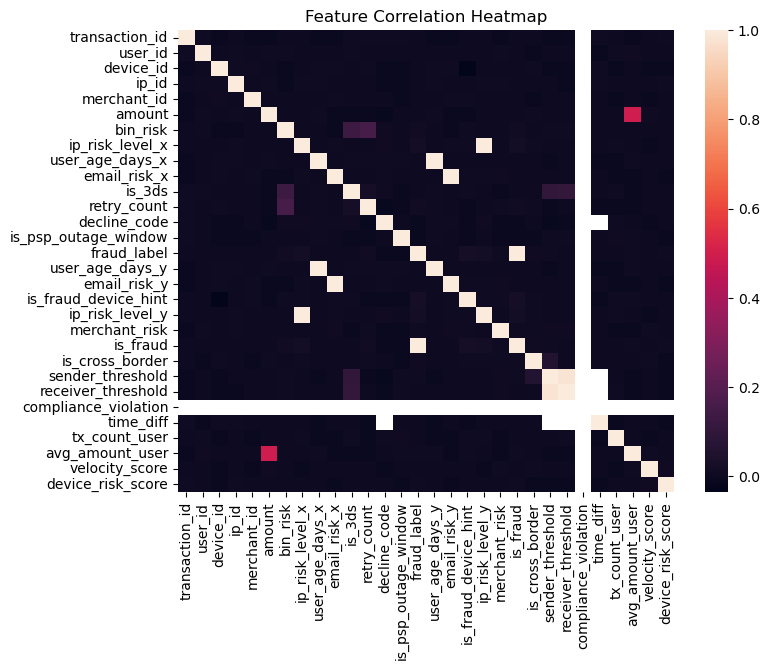

In [7]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

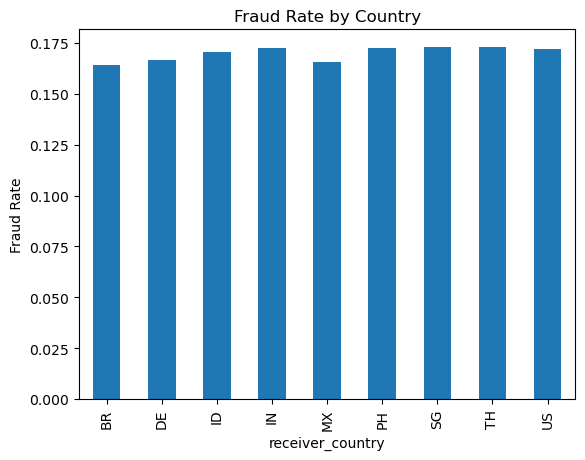

In [8]:
fraud_country = df.groupby("receiver_country")["is_fraud"].mean()

fraud_country.plot(kind="bar")
plt.title("Fraud Rate by Country")
plt.ylabel("Fraud Rate")
plt.show()

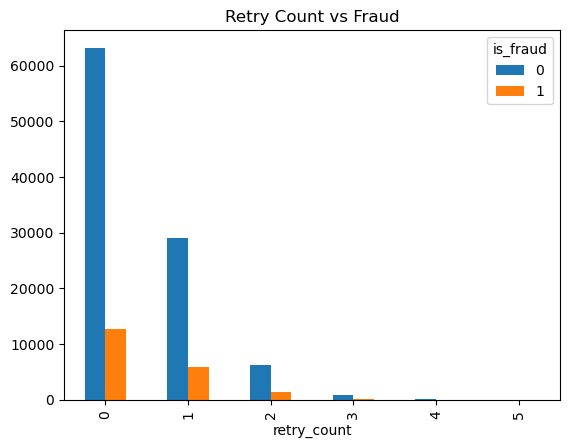

In [9]:
pd.crosstab(df["retry_count"], df["is_fraud"]).plot(kind="bar")
plt.title("Retry Count vs Fraud")
plt.show()

## AGENT IMPLEMENTATION

### Anomaly Detection Agent

In [10]:
from sklearn.ensemble import IsolationForest

class AnomalyAgent:
    def __init__(self):
        self.model = IsolationForest(contamination=0.02)

    def train(self, df):
        self.model.fit(df[["amount","velocity_score","device_risk_score"]])

    def predict(self, df):
        return (self.model.predict(df[["amount","velocity_score","device_risk_score"]]) == -1).astype(int)

### Policy Enforcement Agent

In [11]:
class PolicyAgent:
    def evaluate(self, df):
        return df["compliance_violation"]

### Cross-Domain Risk Agent

In [12]:
class RiskAgent:
    def compute(self, df):
        return (
            0.4 * df["velocity_score"] +
            0.3 * df["device_risk_score"] +
            0.3 * df["is_cross_border"]
        )

### Human-in-the-loop Agent

In [13]:
class HumanAgent:
    def review(self, row):
        if row["amount"] > 20000:
            return 1  # reject
        return 0  # approve

### Audit Layer (Distributed Trust Simulation)

In [14]:
import hashlib

class AuditLayer:
    def __init__(self):
        self.logs = []

    def log(self, row, decision):
        record = str(row["transaction_id"]) + str(decision)
        hash_val = hashlib.sha256(record.encode()).hexdigest()
        self.logs.append(hash_val)

## AGENTIC ORCHESTRATOR

In [15]:
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split

# Features
features = ["amount","velocity_score","device_risk_score","is_cross_border","time_diff"]

X = df[features].fillna(0)
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

In [16]:
from xgboost import XGBClassifier

class MLAgent:
    def __init__(self):
        self.model = XGBClassifier(
            n_estimators=300,
            max_depth=8,
            learning_rate=0.05,
            scale_pos_weight=10,
            random_state=42
        )

    def train(self, X, y):
        self.model.fit(X, y)

    def predict_proba(self, X):
        return self.model.predict_proba(X)[:,1]

class ACS_Orchestrator:
    def __init__(self):
        self.anomaly = AnomalyAgent()
        self.policy = PolicyAgent()
        self.risk = RiskAgent()
        self.human = HumanAgent()
        self.audit = AuditLayer()
        self.ml = MLAgent()   # NEW

    def run(self, df, X_train, y_train, X_test):
        
        # Train agents
        self.anomaly.train(df)
        self.ml.train(X_train, y_train)

        # Predictions
        df["anomaly_flag"] = self.anomaly.predict(df)
        df["policy_flag"] = self.policy.evaluate(df)
        df["risk_score"] = self.risk.compute(df)

        # ML probabilities (IMPORTANT)
        ml_score = self.ml.predict_proba(X_test)

        decisions = []

        for i, (_, row) in enumerate(df.iloc[X_test.index].iterrows()):
            decision = "APPROVED"

            #  FUSION (THIS FIXES YOUR MODEL)
            score = (
                0.75 * ml_score[i] +
                0.15 * row["anomaly_flag"] +
                0.1 * row["policy_flag"]
            )

            if score > 0.8:   # LOWER threshold
                decision = "FLAGGED"

                if self.human.review(row):
                    decision = "REJECTED"

            self.audit.log(row, decision)
            decisions.append(decision)

        result_df = df.iloc[X_test.index].copy()
        result_df["decision"] = decisions

        return result_df

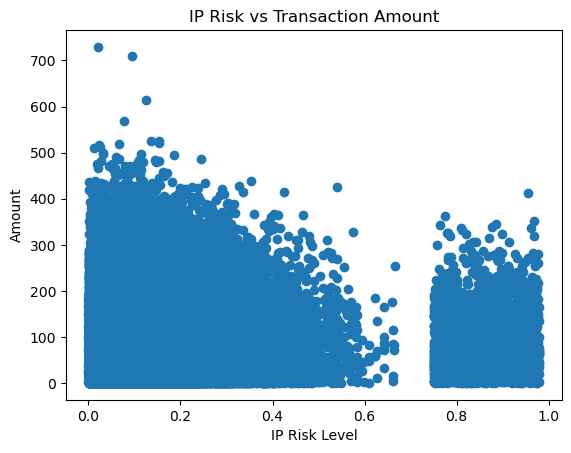

In [17]:
plt.figure()
plt.scatter(df["ip_risk_level_x"], df["amount"])
plt.title("IP Risk vs Transaction Amount")
plt.xlabel("IP Risk Level")
plt.ylabel("Amount")
plt.show()

In [26]:
acs = ACS_Orchestrator()

result_df = acs.run(df, X_train_res, y_train_res, X_test)

y_true = result_df["is_fraud"]
y_pred = (result_df["decision"] != "APPROVED").astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[19330   594]
 [  126  3950]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     19924
           1       0.87      0.97      0.92      4076

    accuracy                           0.97     24000
   macro avg       0.93      0.97      0.95     24000
weighted avg       0.97      0.97      0.97     24000



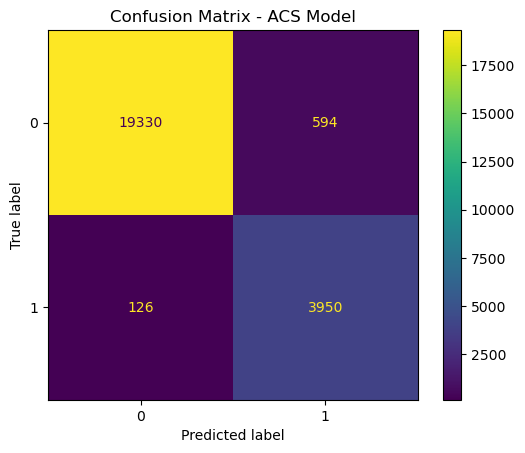

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - ACS Model")
plt.show()